## Model Training — Booking Probability Prediction
Binary classifier estimating $P(Y=1|X)$ for integration into the ranking function:
$$FinalScore = (W_A \times BaseScore) + (W_B \times P(Y=1|X))$$

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    roc_auc_score, classification_report, roc_curve, f1_score
)
from xgboost import XGBClassifier
import joblib

df = pd.read_csv("../data/processed/training_data.csv")
print(f"Dataset: {df.shape}")
df.head()

Dataset: (317277, 28)


,user_id,timestamp,listing_id,Y,days_since_last_review,alltime_review_scores_cleanliness,alltime_review_scores_location,alltime_review_scores_communication,alltime_review_scores_checkin,alltime_review_scores_value,...,recent_review_scores_accuracy,recent_review_scores_rating,reviews_in_last_90_days,property_type,room_type,accommodates,bathrooms,bedrooms,price,neighbourhood_cleansed
0,153564,2009-09-13 11:40:28.184173,1388460895702079744,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,2.0,1.0,1.0,812.0,Bispebjerg
1,61037,2009-10-19 09:44:25.017236,909842584001911808,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,3.0,1.0,3.0,1359.0,Vesterbro-Kongens Enghave
2,162656,2009-11-18 02:16:11.925930,21316502,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,3.0,1.0,1.0,1200.0,Indre By
3,162656,2009-11-18 03:39:25.925930,976307,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,5.0,1.0,3.0,2821.0,Unknown
4,162656,2009-11-18 04:17:51.925930,1330521203094184704,0,-1,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,2.0,1.0,1.0,629.0,Vesterbro-Kongens Enghave


## Data Preprocessing

In [13]:
# Drop columns not used for modeling
drop_cols = ['user_id', 'timestamp', 'listing_id']
df = df.drop(columns=drop_cols)

# Separate target
y = df['Y']
X = df.drop(columns=['Y'])

# Identify column types
cat_cols = ['property_type', 'room_type', 'neighbourhood_cleansed']
num_cols = [c for c in X.columns if c not in cat_cols]

# Impute remaining numeric nulls with median, categoricals with "Unknown"
X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna('Unknown')

print(f"Features: {X.shape[1]} ({len(num_cols)} numeric, {len(cat_cols)} categorical)")
print(f"Categorical cardinalities: {', '.join(f'{c}={X[c].nunique()}' for c in cat_cols)}")
print(f"Missing values: {X.isnull().sum().sum()}")
X.head()

Features: 24 (21 numeric, 3 categorical)
Categorical cardinalities: property_type=8, room_type=5, neighbourhood_cleansed=12
Missing values: 0


,days_since_last_review,alltime_review_scores_cleanliness,alltime_review_scores_location,alltime_review_scores_communication,alltime_review_scores_checkin,alltime_review_scores_value,alltime_review_scores_accuracy,alltime_review_scores_rating,alltime_review_count,recent_review_scores_cleanliness,...,recent_review_scores_accuracy,recent_review_scores_rating,reviews_in_last_90_days,property_type,room_type,accommodates,bathrooms,bedrooms,price,neighbourhood_cleansed
0,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,2.0,1.0,1.0,812.0,Bispebjerg
1,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,3.0,1.0,3.0,1359.0,Vesterbro-Kongens Enghave
2,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,3.0,1.0,1.0,1200.0,Indre By
3,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,5.0,1.0,3.0,2821.0,Unknown
4,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,0.0,0.0,0,Entire rental unit,Entire home/apt,2.0,1.0,1.0,629.0,Vesterbro-Kongens Enghave


In [14]:
# Train / test split (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train Y=1 ratio: {y_train.mean():.4f}")
print(f"Test  Y=1 ratio: {y_test.mean():.4f}")

Train: (253821, 24), Test: (63456, 24)
Train Y=1 ratio: 0.0073
Test  Y=1 ratio: 0.0073


## Encoding & Scaling

In [15]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[cat_cols])

scaler = StandardScaler()
scaler.fit(X_train[num_cols])

def encode_features(X_df, scale=False):
    """Encode categoricals and optionally scale numerics."""
    X_num = X_df[num_cols].copy()
    if scale:
        X_num = scaler.transform(X_num)
    else:
        X_num = X_num.values
    X_cat = encoder.transform(X_df[cat_cols])
    return np.hstack([X_num, X_cat])

feature_names = list(num_cols) + list(encoder.get_feature_names_out(cat_cols))

X_train_enc = encode_features(X_train)
X_test_enc = encode_features(X_test)
X_train_scaled = encode_features(X_train, scale=True)
X_test_scaled = encode_features(X_test, scale=True)

print(f"Encoded features: {len(feature_names)}")
print(f"Train: {X_train_enc.shape}, Test: {X_test_enc.shape}")
print(f"One-hot categories: {encoder.get_feature_names_out(cat_cols).tolist()}")

Encoded features: 46
Train: (253821, 46), Test: (63456, 46)
One-hot categories: ['property_type_Entire condo', 'property_type_Entire home', 'property_type_Entire rental unit', 'property_type_Entire townhouse', 'property_type_Other', 'property_type_Private room in condo', 'property_type_Private room in rental unit', 'property_type_Unknown', 'room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room', 'room_type_Unknown', 'neighbourhood_cleansed_Amager Vest', 'neighbourhood_cleansed_Amager st', 'neighbourhood_cleansed_Bispebjerg', 'neighbourhood_cleansed_Brnshj-Husum', 'neighbourhood_cleansed_Frederiksberg', 'neighbourhood_cleansed_Indre By', 'neighbourhood_cleansed_Nrrebro', 'neighbourhood_cleansed_Unknown', 'neighbourhood_cleansed_Valby', 'neighbourhood_cleansed_Vanlse', 'neighbourhood_cleansed_Vesterbro-Kongens Enghave', 'neighbourhood_cleansed_sterbro']


## Model Training
All models use **weighted loss** to handle the ~137:1 class imbalance.

In [16]:
sample_weights = compute_sample_weight('balanced', y_train)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Imbalance ratio (neg/pos): {scale_pos:.1f}")

models = {
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_pos, random_state=42, eval_metric='logloss'
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42, class_weight='balanced'
    ),
    'LogisticRegression': LogisticRegression(
        max_iter=2000, random_state=42, class_weight='balanced'
    ),
}

results = {}
for name, model in models.items():
    print(f"Training {name}...")

    # Scaled features for LogisticRegression, unscaled for tree-based models
    if name == 'LogisticRegression':
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train_enc, X_test_enc

    if name == 'GradientBoosting':
        model.fit(Xtr, y_train, sample_weight=sample_weights)
    else:
        model.fit(Xtr, y_train)

    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'f1': f1_score(y_test, y_pred),
    }
    print(f"  ROC-AUC: {results[name]['roc_auc']:.4f}, F1: {results[name]['f1']:.4f}")

Imbalance ratio (neg/pos): 136.7
Training XGBoost...
  ROC-AUC: 0.6777, F1: 0.0427
Training GradientBoosting...
  ROC-AUC: 0.6602, F1: 0.0425
Training RandomForest...
  ROC-AUC: 0.6976, F1: 0.0429
Training LogisticRegression...
  ROC-AUC: 0.6791, F1: 0.0346


## Evaluation

In [17]:
# Detailed classification reports
for name, res in results.items():
    print(f"\n{'='*60}")
    print(f"{name}  (ROC-AUC: {res['roc_auc']:.4f})")
    print('='*60)
    print(classification_report(y_test, res['y_pred'], target_names=['No Booking', 'Booking']))


XGBoost  (ROC-AUC: 0.6777)
              precision    recall  f1-score   support

  No Booking       1.00      0.86      0.92     62995
     Booking       0.02      0.44      0.04       461

    accuracy                           0.86     63456
   macro avg       0.51      0.65      0.48     63456
weighted avg       0.99      0.86      0.92     63456


GradientBoosting  (ROC-AUC: 0.6602)
              precision    recall  f1-score   support

  No Booking       1.00      0.87      0.93     62995
     Booking       0.02      0.41      0.04       461

    accuracy                           0.87     63456
   macro avg       0.51      0.64      0.48     63456
weighted avg       0.99      0.87      0.92     63456


RandomForest  (ROC-AUC: 0.6976)
              precision    recall  f1-score   support

  No Booking       0.99      0.88      0.93     62995
     Booking       0.02      0.38      0.04       461

    accuracy                           0.88     63456
   macro avg       0.51      0

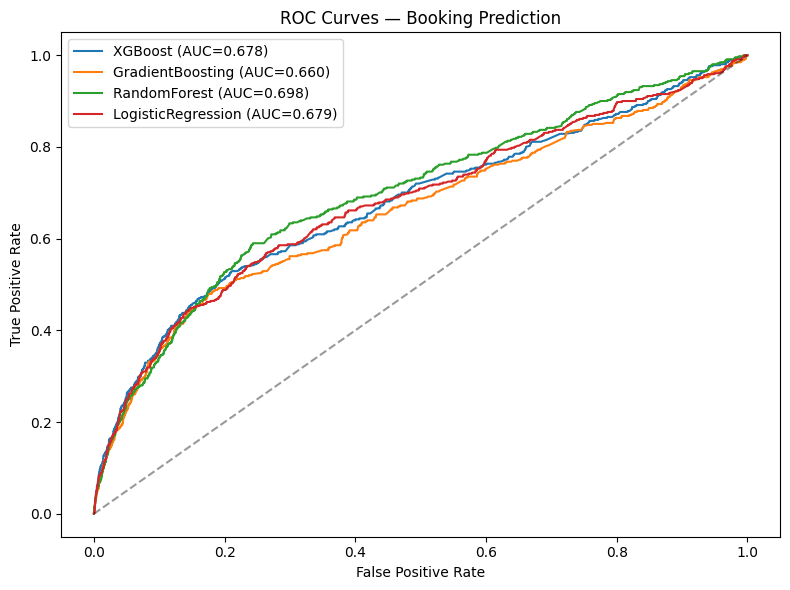

In [18]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Booking Prediction')
ax.legend()
plt.tight_layout()
plt.show()

## Feature Importance

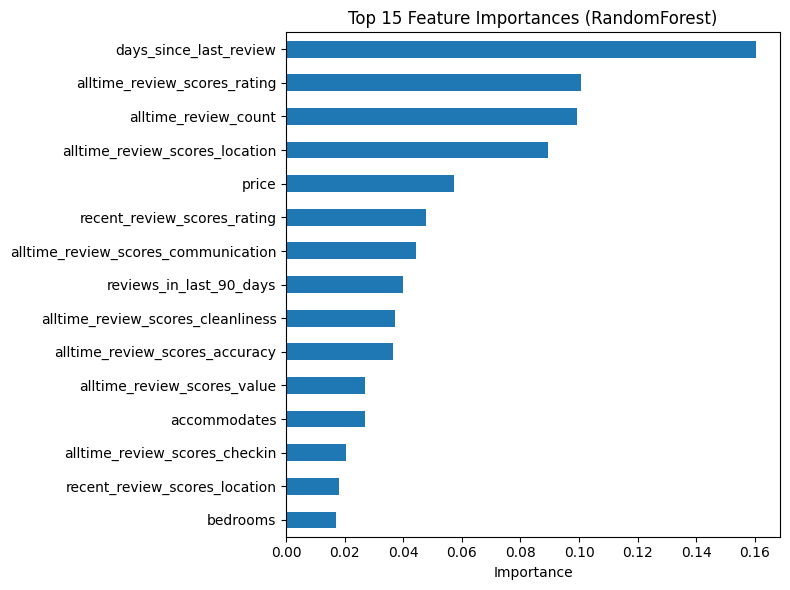

In [19]:
# Feature importance from the best tree-based model
best_name = max(
    [(n, r['roc_auc']) for n, r in results.items() if hasattr(r['model'], 'feature_importances_')],
    key=lambda x: x[1]
)[0]
best_model = results[best_name]['model']

importances = pd.Series(best_model.feature_importances_, index=feature_names)
top_features = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 6))
top_features.plot(kind='barh', ax=ax)
ax.set_title(f'Top 15 Feature Importances ({best_name})')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## Inference

In [20]:
inference_df = pd.read_csv("../data/processed/inference_sample.csv")
inf_ids = inference_df[['user_id', 'timestamp', 'listing_id']].copy()
inf_X = inference_df.drop(columns=['user_id', 'timestamp', 'listing_id', 'Y'], errors='ignore')

inf_X[num_cols] = inf_X[num_cols].fillna(inf_X[num_cols].median())
inf_X[cat_cols] = inf_X[cat_cols].fillna('Unknown')

# Use the fitted encoder/scaler — unknown categories are handled automatically
use_scaling = (best_name == 'LogisticRegression')
inf_encoded = encode_features(inf_X, scale=use_scaling)

# Predict booking probabilities
inf_ids['booking_probability'] = best_model.predict_proba(inf_encoded)[:, 1]

print(f"Inference predictions: {inf_ids.shape}")
print("\nProbability distribution:")
print(inf_ids['booking_probability'].describe())
inf_ids.sort_values('booking_probability', ascending=False).head(10)

Inference predictions: (508, 4)

Probability distribution:
count    508.000000
mean       0.412137
std        0.144330
min        0.143176
25%        0.312816
50%        0.361143
75%        0.494501
max        0.886142
Name: booking_probability, dtype: float64


,user_id,timestamp,listing_id,booking_probability
60,101256025,2025-08-12 07:18:22.759959,53999861,0.886142
343,180946908,2025-08-25 16:31:52.367878,53999861,0.885448
439,6882960,2025-08-30 05:32:23.153638,9054276,0.874721
109,148648748,2025-08-14 11:39:27.817553,733041040667070208,0.860709
376,710318177,2025-08-26 17:49:16.782989,37182790,0.853994
249,558848637,2025-08-21 12:39:58.359285,16809364,0.849311
312,240603585,2025-08-24 16:56:50.715732,6181515,0.847648
107,148648748,2025-08-14 10:40:20.817553,6181515,0.842982
499,37996318,2025-09-05 19:42:34.047350,42560475,0.827026
7,485359583,2025-08-09 23:44:32.522071,10645628,0.818846


In [21]:
# Save the best model, preprocessing artifacts, and predictions
joblib.dump(best_model, f"../data/processed/{best_name}_model.joblib")
joblib.dump(encoder, "../data/processed/onehot_encoder.joblib")
joblib.dump(scaler, "../data/processed/standard_scaler.joblib")
joblib.dump(feature_names, "../data/processed/feature_columns.joblib")
joblib.dump({'num_cols': num_cols, 'cat_cols': cat_cols}, "../data/processed/column_config.joblib")
inf_ids.to_csv("../data/processed/inference_predictions.csv", index=False)

print(f"Saved {best_name} model + encoder + scaler + predictions to data/processed/")

Saved RandomForest model + encoder + scaler + predictions to data/processed/
